# vega-mir: an introductory tour

This notebook walks through the **nine information-theoretic metrics**
shipped in `vega-mir` on small synthetic examples whose answers are
known analytically. The point is not to extract conclusions from real
music but to show, metric by metric, what each function measures and
how its return value should be read.

For the matching real-world demonstration on bundled scale-degree
sequences, see [02_paper_reproduction.ipynb](02_paper_reproduction.ipynb).

In [1]:
import math
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import vega_mir
print(f"vega-mir {vega_mir.__version__}")

vega-mir 0.0.1


## 1. Shannon entropy

`shannon_entropy(probs)` measures the uncertainty in a probability
vector in bits (`log2`). Two analytic anchors:

- **uniform on N symbols** → `H = log2(N)` (maximum)
- **deterministic** (one symbol takes all mass) → `H = 0` (minimum)

In [2]:
H_uniform_2 = vega_mir.shannon_entropy(np.array([0.5, 0.5]))
H_uniform_15 = vega_mir.shannon_entropy(np.full(15, 1/15))
H_deterministic = vega_mir.shannon_entropy(np.array([1.0, 0.0, 0.0]))

print(f"H(uniform on 2)   = {H_uniform_2:.4f} bits  (expected log2(2) = 1)")
print(f"H(uniform on 15)  = {H_uniform_15:.4f} bits  (expected log2(15) = {math.log2(15):.4f})")
print(f"H(deterministic) = {H_deterministic:.4f} bits  (expected 0)")

H(uniform on 2)   = 1.0000 bits  (expected log2(2) = 1)
H(uniform on 15)  = 3.9069 bits  (expected log2(15) = 3.9069)
H(deterministic) = -0.0000 bits  (expected 0)


The high-level convenience `shannon_scale_degrees(seq)` consumes a
chord/scale-degree sequence directly, with the Cygnus methodology
defaults (`alpha = 0.5` Jeffreys smoothing, base 2, collapse repeated
chords, 15-symbol alphabet).

In [3]:
seq = ["I", "V", "vi", "IV"] * 25  # a Pop ‘50s loop
H = vega_mir.shannon_scale_degrees(seq)
print(f"H(I-V-vi-IV loop) = {H:.4f} bits  (4 distinct symbols on a 15-alphabet w/ smoothing)")

H(I-V-vi-IV loop) = 2.1064 bits  (4 distinct symbols on a 15-alphabet w/ smoothing)


## 2. Zipf's law

`zipf_fit(probs)` performs an OLS fit of `log2(P) = C - alpha * log2(rank)`
on a probability vector. Two analytic anchors:

- generated as `P_i ∝ 1/i` → `alpha ≈ 1`, `R² ≈ 1`
- generated as `P_i ∝ 1/i²` → `alpha ≈ 2`, `R² ≈ 1`

In [4]:
n = 30
ranks = np.arange(1, n + 1, dtype=float)

probs_z1 = 1 / ranks ; probs_z1 /= probs_z1.sum()
probs_z2 = 1 / ranks**2 ; probs_z2 /= probs_z2.sum()

z1 = vega_mir.zipf_fit(probs_z1)
z2 = vega_mir.zipf_fit(probs_z2)
zu = vega_mir.zipf_fit(np.full(n, 1/n))

print(f"P_i ∝ 1/i   → alpha = {z1.alpha:.4f}, R² = {z1.r_squared:.4f}")
print(f"P_i ∝ 1/i²  → alpha = {z2.alpha:.4f}, R² = {z2.r_squared:.4f}")
print(f"uniform     → alpha = {zu.alpha:.4f}")

P_i ∝ 1/i   → alpha = 1.0000, R² = 1.0000
P_i ∝ 1/i²  → alpha = 2.0000, R² = 1.0000
uniform     → alpha = 0.0000


## 3. Kullback-Leibler and Jensen-Shannon divergences

`kl_divergence(p, q)` is the asymmetric KL in bits with the convention
`0 log 0 = 0`. `js_divergence(p, q)` is the symmetric variant, bounded
in `[0, 1]` for log base 2.

Analytic anchors:

- `D(P || P) = 0` (self-divergence)
- `D(Bern(0.5) || Bern(0.25)) = 1 - 0.5 * log2(3) ≈ 0.208`
- `JS(δ_a, δ_b) = 1` (maximum, disjoint supports)

In [5]:
p = np.array([0.5, 0.5])
q = np.array([0.25, 0.75])

print(f"D(P || P)        = {vega_mir.kl_divergence(p, p):.4f}")
print(f"D(P || Q)        = {vega_mir.kl_divergence(p, q):.4f}  (expected {1 - 0.5 * math.log2(3):.4f})")
print(f"D(Q || P)        = {vega_mir.kl_divergence(q, p):.4f}  (≠ D(P||Q): asymmetric)")
print(f"JS(P, Q)         = {vega_mir.js_divergence(p, q):.4f}  (symmetric)")

delta_a = np.array([1.0, 0.0])
delta_b = np.array([0.0, 1.0])
print(f"JS(δ_a, δ_b)     = {vega_mir.js_divergence(delta_a, delta_b):.4f}  (max = 1)")

D(P || P)        = 0.0000
D(P || Q)        = 0.2075  (expected 0.2075)
D(Q || P)        = 0.1887  (≠ D(P||Q): asymmetric)
JS(P, Q)         = 0.0488  (symmetric)
JS(δ_a, δ_b)     = 1.0000  (max = 1)


## 4. Gini coefficient

`gini(values)` measures the inequality of a non-negative sample.

- uniform values → `G = 0` (perfectly equal)
- all mass on one entry → `G = (n-1)/n` (maximally unequal)
- analytic value: `gini([1, 2, 3, 4]) = 0.25`

In [6]:
print(f"G(uniform 4)        = {vega_mir.gini([1, 1, 1, 1]):.4f}")
print(f"G([1, 2, 3, 4])     = {vega_mir.gini([1, 2, 3, 4]):.4f}  (expected 0.25)")
print(f"G(all-on-one)       = {vega_mir.gini([1, 0, 0, 0]):.4f}  (expected (n-1)/n = 0.75)")
print(f"G([10, 20, 30, 40]) = {vega_mir.gini([10, 20, 30, 40]):.4f}  (scale-invariant)")

G(uniform 4)        = 0.0000
G([1, 2, 3, 4])     = 0.2500  (expected 0.25)
G(all-on-one)       = 0.7500  (expected (n-1)/n = 0.75)
G([10, 20, 30, 40]) = 0.2500  (scale-invariant)


## 5. Stationarity (chi² contingency)

`stationarity_test(seq)` splits a symbolic sequence into `n_segments`
equal parts and runs Pearson's chi² on the segments-by-symbols
contingency table. Cramer's V is the effect size in `[0, 1]`.

- repeated pattern across segments → `cramers_v ≈ 0`, `is_stationary = True`
- concatenated disjoint distributions → `cramers_v ≈ 1`, `is_stationary = False`

In [7]:
seq_stat = ["I", "V", "IV", "vi", "ii"] * 40   # identical content per segment
seq_drift = ["I"] * 100 + ["V"] * 100           # disjoint segments

r_stat = vega_mir.stationarity_test(seq_stat, n_segments=4)
r_drift = vega_mir.stationarity_test(seq_drift, n_segments=4)

print(f"Repeated pattern  : cramers_v = {r_stat.cramers_v:.4f}  is_stationary = {r_stat.is_stationary}")
print(f"Concatenated drift: cramers_v = {r_drift.cramers_v:.4f}  is_stationary = {r_drift.is_stationary}")

Repeated pattern  : cramers_v = 0.0000  is_stationary = True
Concatenated drift: cramers_v = 1.0000  is_stationary = False


## 6. Interval distribution fits

`fit_intervals(intervals)` MLE-fits Exponential and Laplace distributions
on absolute melodic intervals, scores each by KS, and reports the
winner along with summary statistics (`pct_conjunct` for `|interval| ≤ 2`,
`pct_leaps` for `|interval| > 4`).

In [8]:
rng = np.random.default_rng(42)
sample_exp = rng.exponential(scale=2.0, size=2000)
fit = vega_mir.fit_intervals(sample_exp)
print(f"Pure exponential sample → best_fit = {fit.best_fit}, lambda = {fit.exponential_lambda:.3f} (expected 0.5)")

sample_small = [0, 1, 2, 1, 2, 0, 1, 2, 1, 2]
fit_small = vega_mir.fit_intervals(sample_small)
print(f"All small intervals    → pct_conjunct = {fit_small.pct_conjunct:.1f}%, pct_leaps = {fit_small.pct_leaps:.1f}%")

Pure exponential sample → best_fit = exponential, lambda = 0.493 (expected 0.5)
All small intervals    → pct_conjunct = 100.0%, pct_leaps = 0.0%


## 7. Network analysis on a chord graph

`chord_graph_from_sequence(seq)` builds a directed weighted graph whose
edges are bigram transitions normalized per source. `network_analysis(g)`
returns PageRank, mean clustering, communities, and a small-world flag.

In [9]:
g = vega_mir.chord_graph_from_sequence(["I", "V", "vi", "IV", "ii"] * 30)
result = vega_mir.network_analysis(g)
print(f"n_nodes              = {result.n_nodes}")
print(f"density              = {result.density:.4f}")
print(f"gravity_center       = {result.gravity_center}")
print(f"mean_clustering      = {result.mean_clustering:.4f}")
print(f"n_communities        = {result.n_communities}")
print(f"avg_shortest_path    = {result.avg_shortest_path:.4f}")
print(f"small_world_candidate = {result.small_world_candidate}")
print()
print("PageRank (sums to 1):")
for node, score in sorted(result.pagerank.items(), key=lambda x: -x[1]):
    print(f"  {node:<6} {score:.4f}")

n_nodes              = 5
density              = 0.2500
gravity_center       = I
mean_clustering      = 0.0000
n_communities        = 2
avg_shortest_path    = 2.5000
small_world_candidate = False

PageRank (sums to 1):
  I      0.2000
  V      0.2000
  vi     0.2000
  IV     0.2000
  ii     0.2000


## 8. Higuchi fractal dimension

`higuchi_fractal_dimension(time_series)` recovers the fractal dimension
from the slope of `log <L(k)> vs log k`. Theoretical anchors:

- linear ramp / sine wave (smooth) → `D ≈ 1`
- Brownian motion (random walk) → `D ≈ 1.5`
- white Gaussian noise → `D ≈ 2`

In [10]:
rng = np.random.default_rng(42)

ramp = np.arange(2000, dtype=float)
brown = np.cumsum(rng.normal(size=2000))
white = rng.normal(size=2000)

print(f"Linear ramp     → D = {vega_mir.higuchi_fractal_dimension(ramp).dimension:.4f}  (expected ~1.0)")
print(f"Brownian motion → D = {vega_mir.higuchi_fractal_dimension(brown).dimension:.4f}  (expected ~1.5)")
print(f"White noise     → D = {vega_mir.higuchi_fractal_dimension(white).dimension:.4f}  (expected ~2.0)")

Linear ramp     → D = 1.0000  (expected ~1.0)
Brownian motion → D = 1.4789  (expected ~1.5)
White noise     → D = 1.9903  (expected ~2.0)


## 9. Rubato spectral analysis

`rubato_spectral(bpm_curve)` performs an FFT on the centered tempo curve,
identifies dominant peaks, computes a periodicity ratio, and classifies
the rubato as one of `{periodic, quasi_periodic, free, metronomic}`.

In [11]:
rng = np.random.default_rng(42)
n = 400
i = np.arange(n)

flat   = np.full(n, 120.0)
sine   = 120 + 8.0 * np.sin(2 * np.pi * 0.05 * i)              # period = 20 samples
brown  = 120 + np.cumsum(rng.normal(scale=1.5, size=n))         # 1/f² spectrum

for label, bpm in [("Flat tempo", flat), ("Pure sinusoid", sine), ("Brownian drift", brown)]:
    r = vega_mir.rubato_spectral(bpm)
    print(f"{label:<18} → type = {r.rubato_type:<14} ratio = {r.periodicity_ratio:.4f} std = {r.tempo_std:.2f} BPM")

Flat tempo         → type = metronomic     ratio = 0.0000 std = 0.00 BPM
Pure sinusoid      → type = periodic       ratio = 1.0000 std = 5.66 BPM
Brownian drift     → type = free           ratio = 0.0955 std = 7.30 BPM


## Visual summary: how the metrics behave under increasing entropy

To close the tour, here is a single figure showing how Shannon entropy
and Gini coefficient track the "spread" of mass across an alphabet of 15.

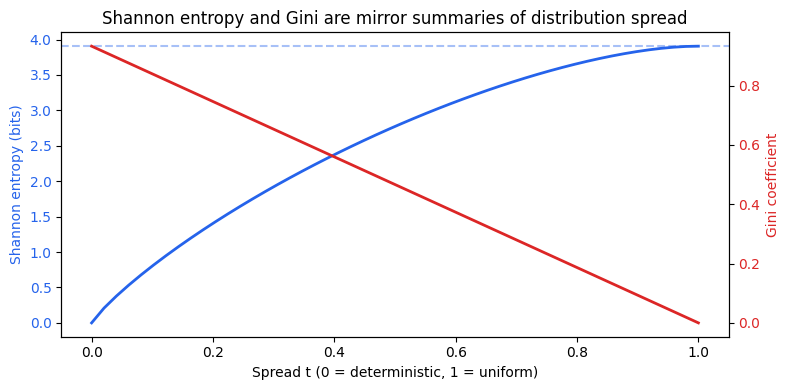

In [12]:
alphabet_size = 15
ts = np.linspace(0, 1, 50)  # 0 = deterministic, 1 = uniform
H_curve = []
G_curve = []
for t in ts:
    probs = np.full(alphabet_size, t / alphabet_size)
    probs[0] += (1 - t)
    H_curve.append(vega_mir.shannon_entropy(probs))
    G_curve.append(vega_mir.gini(probs))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(ts, H_curve, label="Shannon entropy (bits)", color="#2563eb", linewidth=2)
ax1.set_xlabel("Spread t (0 = deterministic, 1 = uniform)")
ax1.set_ylabel("Shannon entropy (bits)", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")
ax1.axhline(math.log2(alphabet_size), linestyle="--", color="#2563eb", alpha=0.4, label="log2(15)")

ax2 = ax1.twinx()
ax2.plot(ts, G_curve, label="Gini", color="#dc2626", linewidth=2)
ax2.set_ylabel("Gini coefficient", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")

plt.title("Shannon entropy and Gini are mirror summaries of distribution spread")
fig.tight_layout()
plt.show()

## Where to next

- **[02_paper_reproduction.ipynb](02_paper_reproduction.ipynb)** —
  recover three flagship findings of the Cygnus arXiv paper from the
  bundled real scale-degree counts.
- **GitHub** — [fredericjalbertdesforges/vega-mir](https://github.com/fredericjalbertdesforges/vega-mir)
- **Citation** — see `CITATION.cff` at the repo root.